Physical modelling

In [1]:
import math

print("All units in metres")
building_height = 15 #m, 3 storeys, max. 5m per storey [hb]
sensor_height = 10 #m, below building [hr]
building_distance = 10 #m, measured using google maps [d/2]
drone_height = 100 #m, fixed value [hd]
drone_distance = 850 #m, simulation value [R + d/2]

# radar

# angles in degrees
min_beam_angle_radar = 3
width_beam_angle_radar = 65

visible_angle = math.degrees(math.atan((building_height - sensor_height) / building_distance)) #minimum angle visible by radar, unobstructed by building
min_beam_angle_visible_radar = max(min_beam_angle_radar, visible_angle)

beam_distance = math.sqrt ((drone_height - sensor_height)**2 + (drone_distance)**2 )

max_detectable_height_radar = (drone_distance * math.tan(math.radians(min_beam_angle_radar + width_beam_angle_radar))) + sensor_height
min_detectable_height_radar = (drone_distance * math.tan(math.radians(min_beam_angle_visible_radar))) + sensor_height

if min_detectable_height_radar <= drone_height <= max_detectable_height_radar and beam_distance < 3000:
  print("Drone in line of sight of Radar")
else:
  print("Drone not in line of sight of Radar")

# radio frequency

# angles in degrees
min_beam_angle_rf = 3
width_beam_angle_rf = 45

min_beam_angle_visible_rf = max(min_beam_angle_rf, visible_angle)

max_detectable_height_rf = (drone_distance * math.tan(math.radians(min_beam_angle_rf + width_beam_angle_rf))) + sensor_height
min_detectable_height_rf = (drone_distance * math.tan(math.radians(min_beam_angle_visible_rf))) + sensor_height

if min_detectable_height_rf <= drone_height <= max_detectable_height_rf and beam_distance < 1000:
  print("Drone in line of sight of Radio Frequency")
else:
  print("Drone not in line of sight of Radio Frequency")

All units in metres
Drone not in line of sight of Radar
Drone not in line of sight of Radio Frequency


In [2]:
!pip3 install ColabTurtlePlus

In [3]:
import ColabTurtlePlus.Turtle as t
from scipy.interpolate import interp1d
import numpy as np

# initialisation
window_width = 1000
window_height = 550
k = min(window_width / 1.15 / drone_distance, window_height / 1.15 / drone_height) #scaling factor

t.clearscreen()
t.setup(window_width, window_height)
t.showborder()

t.pensize(2)
t.hideturtle()
t.speed(0)
t.face(90)

# marking points
def draw_cross(size):
  t.right(45)
  t.forward(size)
  t.backward(size)
  for i in range(3):
    t.right(90)
    t.forward(size)
    t.backward(size)
  t.right(45)

def dotted_line(distance):
  moved = 0
  while moved < distance - 20:
    t.pendown()
    t.forward(13)
    t.penup()
    t.forward(7)
    moved += 20
  t.pendown()
  t.forward(distance-moved)

# sensor tower
t.penup()
t.goto(-window_width/2 + 10, -window_height/2)
initial_pos = t.position()


# buildings
t.penup()
t.face(180)
t.forward(k + building_distance * k)
t.right(90)
t.color("black")

t.forward(building_height*k)
t.right(90)
t.forward(2*k)
t.right(90)
t.forward(building_height*k)
t.penup()

t.face(0)
t.forward(building_distance * 2 * k - 2 * k)
t.left(90)
t.pendown()
t.forward(building_height*k)
t.right(90)
t.forward(2*k)
t.right(90)
t.forward(building_height*k)
t.penup()

t.color("green")
t.goto(initial_pos)
t.pendown()
t.face(90)
t.forward(sensor_height * k)
sensor_pos = t.position()

# radar beams

# lower bound
t.color((128, 128, 255))
t.face(0)
t.left(min_beam_angle_radar)
t.pendown()
dotted_line(3000*k)

# lower bound (building)
t.penup()
t.goto(sensor_pos)
t.face(0)
t.left(min_beam_angle_visible_radar)
t.pendown()
t.forward(3000*k)

# upper bound
t.penup()
t.goto(sensor_pos)
t.face(0)
t.left(min_beam_angle_radar + width_beam_angle_radar)
t.pendown()
t.forward(3000*k)
radar_pos = t.position()

# detectable range circle
t.right(90)
radar_circle_heading = t.getheading()
t.circle(-3000*k, width_beam_angle_radar)
t.penup()

# shade detectable ranges
t.goto(radar_pos)
t.face(radar_circle_heading)
t.fillcolor(128, 128, 255)
t.fillopacity(0.3)
t.begin_fill()
t.circle(-3000*k, width_beam_angle_radar - (min_beam_angle_visible_radar - min_beam_angle_radar))
t.goto(sensor_pos)
t.goto(radar_pos)
t.end_fill()


# RF beams

# lower bound
t.color((255, 128, 128))
t.penup()
t.goto(sensor_pos)
t.face(0)
t.left(min_beam_angle_rf)
t.pendown()
dotted_line(1000*k)

# lower bound (building)
t.penup()
t.goto(sensor_pos)
t.face(0)
t.left(min_beam_angle_visible_rf)
t.pendown()
t.forward(1000*k)

# upper bound
t.penup()
t.goto(sensor_pos)
t.face(0)
t.left(min_beam_angle_rf + width_beam_angle_rf)
t.pendown()
t.forward(1000*k)
rf_pos = t.position()

# detectable range circle
t.right(90)
rf_circle_heading = t.getheading()
t.circle(-1000*k, width_beam_angle_rf)
t.penup()

# shade detectable ranges
t.goto(rf_pos)
t.face(rf_circle_heading)
t.fillcolor(255, 128, 128)
t.fillopacity(0.3)
t.begin_fill()
t.circle(-1000*k, width_beam_angle_rf - (min_beam_angle_visible_rf - min_beam_angle_rf))
t.goto(sensor_pos)
t.goto(rf_pos)
t.end_fill()

# drone beam
t.penup()
t.goto(sensor_pos)
t.face(270)
t.penup()
t.forward(sensor_height * k)
t.left(90)
t.forward(drone_distance * k)
t.left(90)
t.forward(drone_height * k) # goes to drone position
angle = math.degrees(math.atan((drone_height - sensor_height) / drone_distance)) + 180
t.face(angle)
dist = math.sqrt((drone_height - sensor_height) ** 2 + drone_distance ** 2) * k
dotted_line(dist)

# sensor position
t.goto(sensor_pos)
t.color("green")
t.face(270)
t.pendown()
draw_cross(10)
t.face(90)
t.penup()
t.forward(15)
t.write("Receiver", align="left", font=("Arial", 15, "normal"))

# drone position
t.penup()
t.goto(sensor_pos)
t.face(270)
t.forward(sensor_height * k)
t.left(90)
t.forward(drone_distance * k)
t.left(90)
t.forward(drone_height * k)
t.color("red")
t.pendown()
draw_cross(10)
t.penup()
t.face(90)
t.forward(15)
t.write("Drone", align="center", font=("Arial", 15, "normal"))



# finish and display
t.done()

Put clearscreen() as the first line in a cell (after the import command) to re-run turtle commands in the cell


RF receiver modelling

In [4]:
# RF propagation models (functions)

# frequency (MHz) : power_transmission (dBm)
drone_info = {
    433 : 10,
    868 : 14,
    900 : 20,
    2400 : 20,
    5800 : 20,
}
power_receive = -90 # dBm

d = building_distance * 2 # dist between 2 buildings
H = drone_height - building_height

# Free Space Path Loss Model
def FSPLoss(frequency, R):
  B = math.sqrt((R + (d/2))**2 + (drone_height-sensor_height)**2)
  Lf = -27.6 + 20*math.log(frequency, 10) + 20*math.log(B, 10)
  return Lf

# Walfisch-Bertoni Model
def WBLoss(frequency, R):
  Lf = -27.6 + 20*math.log(frequency, 10) + 20*math.log(R, 10)
  Lmsd = 68.9 - 9*math.log(frequency, 10) - 9*math.log(d, 10) + 18*math.log( R/1000, 10) - 18*math.log(H, 10) - 18*math.log(1- ((R / 1000)** 2 /(17 * H)) ,10 )
  Lrts = -8.8 + 10*math.log(frequency, 10) + 5*math.log((d/2)**2 + (building_height - sensor_height) ** 2, 10) + 20*math.log(math.atan((2 * (building_height - sensor_height) / d)), 10)
  L = Lf + Lmsd + Lrts
  return L

# Walfisch-Bertoni Model Modified
def WBMLoss(frequency, R):
  Lf = FSPLoss(frequency, R)
  alpha = math.atan(H / R)
  Lrts = -11.5 + 10*math.log(frequency, 10) + 5*math.log((d / 2) ** 2 + (building_height - sensor_height) ** 2, 10) + 20*math.log(math.atan((2 * (building_height - sensor_height) / d)) - alpha, 10)
  Lmr = (2 * (building_height - sensor_height) * R - d * H) / (2 * d * H) * 8

  Q = alpha * math.sqrt((frequency * 10 ** 6 * d) / (299792458)) # c = 299792458m/s
  Lmsd = 0
  if Q < 0.4:
    Lmsd = 16.8 + 20*math.log(R, 10) - 20*math.log(H, 10) - 10*math.log(frequency, 10) - 10*math.log(d, 10)

  L = Lf + Lmsd + min(Lmr, Lrts)
  return L

# Weissberger's model
def WeissbergerLoss(frequency, R):
  Lf = FSPLoss(frequency, R)
  Lfoliage = 0
  if(0 <= (R + d/2) <= 14):
    Lfoliage = 0.45 * ((frequency / 1000) ** 0.284) * (R + d/2)
  else:
    Lfoliage = 1.33 * ((frequency / 1000) ** 0.284) * ((R + d/2) ** 0.588)

  L = Lf + Lfoliage
  return L

# FITU-R model
def FITUR(frequency, R):
  Lf = FSPLoss(frequency, R)
  #Lf = 40*math.log(R + d/2, 10) - 20*math.log(sensor_height*drone_height, 10) #plane earth model
  Lfoliage = 0.39*((frequency/1000) ** 0.39) * (R+d/2) ** 0.25
  L = Lf + Lfoliage
  return L

def findTarget(L_target, method, f):
  R = 500
  L = 0

  val = []
  while True:
    if R in val:
      return [1000, -1]
    else:
      val.append(R)

    if method == "FSPL":
      L = FSPLoss(f, R)
    elif method == "WB":
      L = WBLoss(f, R)
    elif method == "WBM":
      L = WBMLoss(f, R)
    elif method == "Weissberger":
      L = WeissbergerLoss(f, R)
    elif method == "FITU-R":
      L = FITUR(f, R)
    else:
      return 0

    change = 0

    if abs(L - L_target) > 5:
      change = 100
    elif abs(L - L_target) > 2:
      change = 50
    elif abs(L - L_target) > 0.5:
      change = 5
    elif abs(L-L_target) > 0.2:
      change = 0.5
    else:
      break

    if L > L_target:
      R -= change
    elif L < L_target:
      R += change


  B = round(math.sqrt((R + d/2) ** 2 + (H + building_height + sensor_height) ** 2), 2)
  return [B, L]

def getValues(lower_bound, upper_bound, method, step, f):
  power_transmission = drone_info[f]
  x = [1]
  y = [power_transmission]
  for i in range(lower_bound, upper_bound, step):
    x.append(round(math.sqrt((i + d/2) ** 2 + (H + building_height + sensor_height) ** 2), 2)) # calculate B from R
    try:
      if method == "FSPL":
        y.append(power_transmission - FSPLoss(f, i))
      elif method == "WB":
        y.append(power_transmission - WBLoss(f, i))
      elif method == "WBM":
        y.append(power_transmission - WBMLoss(f, i))
      elif method == "Weissberger":
        y.append(power_transmission - WeissbergerLoss(f, i))
      elif method == "FITU-R":
        y.append(power_transmission - FITUR(f, i))
      else:
        return 0
    except:
      x.pop()
      continue
  return [x, y]

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!wget "https://github.com/google/fonts/raw/main/apache/tinos/Tinos-Regular.ttf"
!wget "https://github.com/google/fonts/raw/main/apache/tinos/Tinos-Bold.ttf"

font_files = fm.findSystemFonts('.')

for font_file in font_files:
  print(font_file)
  fm.fontManager.addfont(font_file)

--2026-02-20 02:33:42--  https://github.com/google/fonts/raw/main/apache/tinos/Tinos-Regular.ttf
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/apache/tinos/Tinos-Regular.ttf [following]
--2026-02-20 02:33:43--  https://raw.githubusercontent.com/google/fonts/main/apache/tinos/Tinos-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 475288 (464K) [application/octet-stream]
Saving to: ‘Tinos-Regular.ttf’

Tinos-Regular.ttf   100%[===================>] 464.15K  --.-KB/s    in 0.1s    

2026-02-20 02:33:43 (3.50 MB/s) - ‘Tinos-Regular.ttf’ saved [475288/475288]

--2026-

<Figure size 640x480 with 0 Axes>

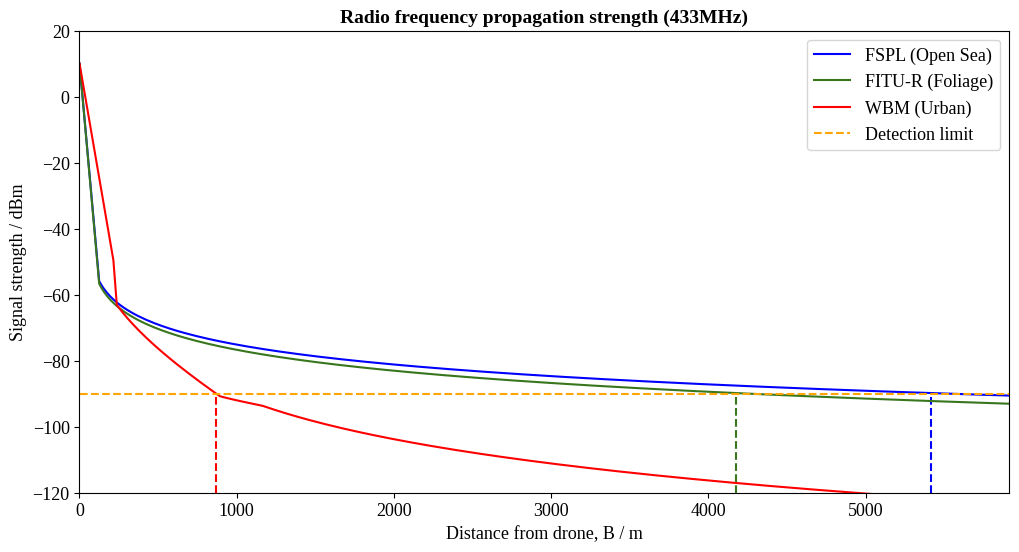

<Figure size 640x480 with 0 Axes>

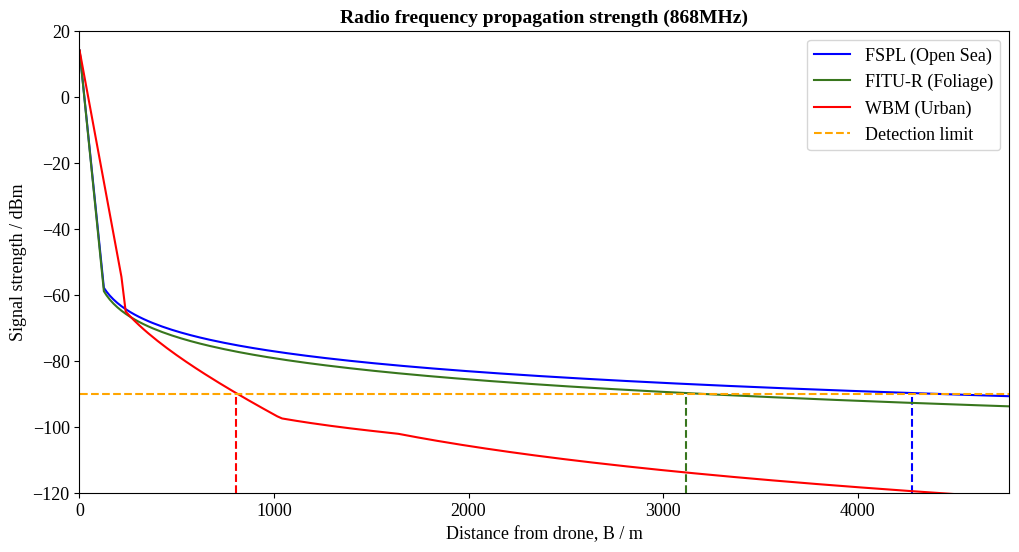

<Figure size 640x480 with 0 Axes>

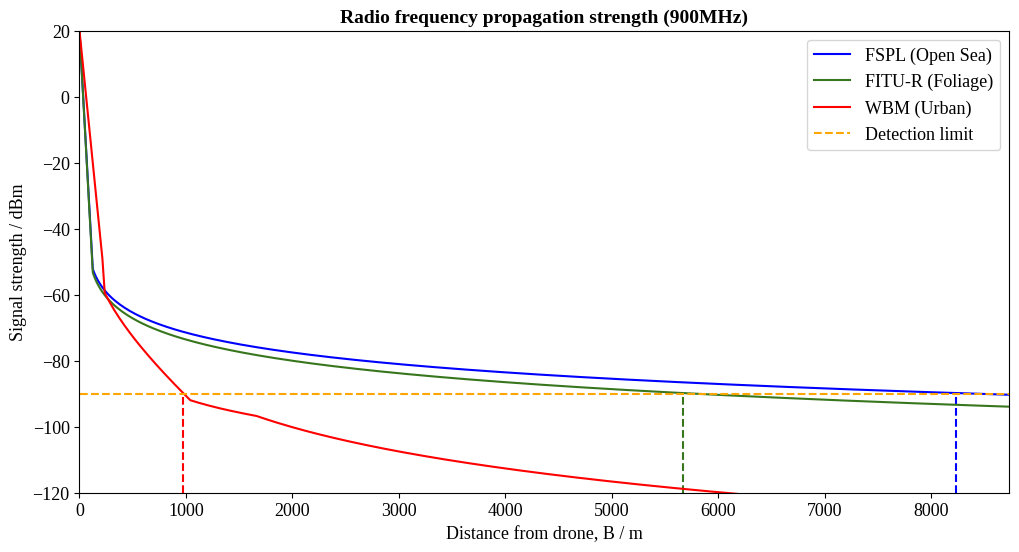

<Figure size 640x480 with 0 Axes>

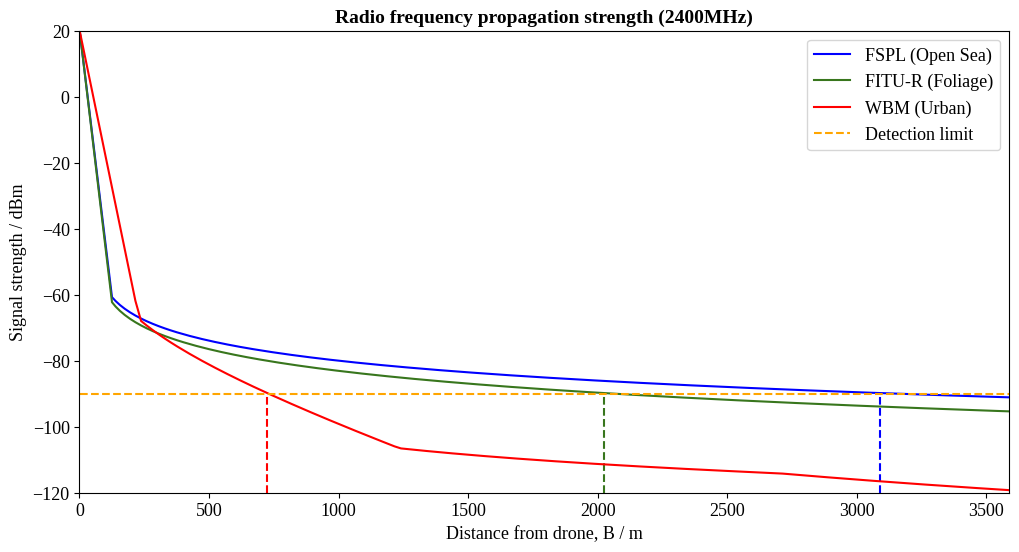

<Figure size 640x480 with 0 Axes>

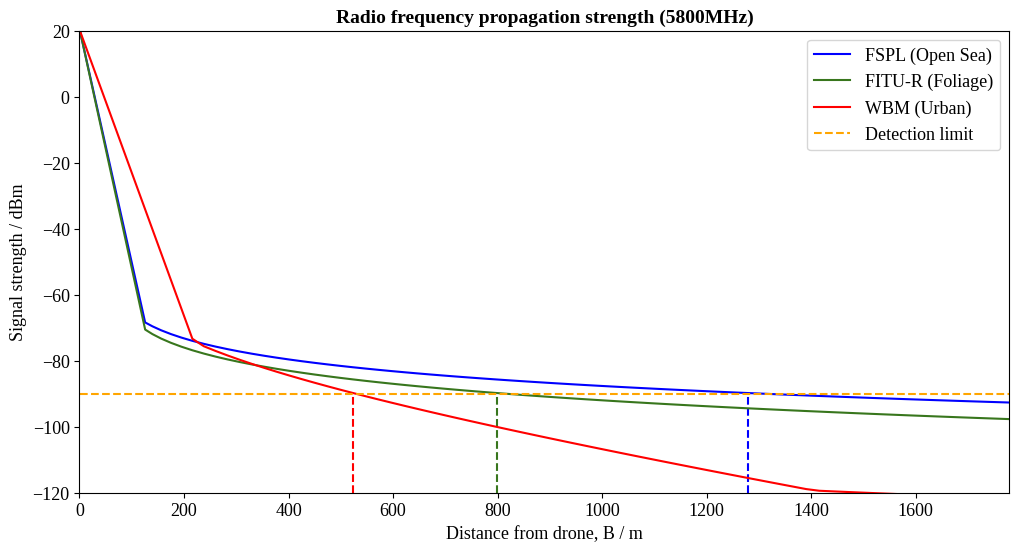

In [6]:
# plotting signal strength over distance

%matplotlib inline
plt.rcParams.update({'font.size': 13, 'font.family': "Tinos"})

frequencies = [433, 868, 900, 2400, 5800]
methods = ["FSPL", "FITU-R", "WBM"]
legend_labels = {
    "FSPL": "FSPL (Open Sea)",
    "FITU-R": "FITU-R (Foliage)",
    "WBM": "WBM (Urban)"
}
color = {
      "FSPL": "#0000ff",
      "WB": "orange",
      "WBM": "#ff0000",
      "Weissberger": "#38761d",
      "FITU-R": "#38761d"
}


# plot for all frequencies
for f in frequencies:
  # clear and set up graph
  plt.clf()
  fig, ax = plt.subplots()
  ax.set_xlabel("Distance from drone, B / m")
  ax.set_ylabel("Signal strength / dBm")
  ax.set_title("Radio frequency propagation strength (" + str(f) + "MHz)", fontsize=14, fontweight="bold")

  # plot for all methods

  # calculate max x-value
  limits = []
  for method in methods:
    power_transmission = drone_info[f]
    limits.append(findTarget(power_transmission - power_receive, method, f)[0])

  # plot points
  for index, method in enumerate(methods):
    points = getValues(51, int(max(limits[:])) + 1000, method, 25, f)
    ax.plot(points[0], points[1], label=legend_labels[method], color=color[method])
    ax.plot([limits[index], limits[index]], [-120, power_receive], linestyle="--", color=color[method])

  # plot detection limit
  ax.plot([1, int(max(limits)) + 500], [power_receive, power_receive], linestyle="--", label="Detection limit", color="orange")

  # set graph limits
  plt.xlim(0, int(max(limits)) + 500)
  plt.ylim(-120, 20)
  ax.legend(fontsize=13)

  # config
  fig.set_figwidth(12)
  fig.set_figheight(6)

  # show and save
  plt.show()
  fig.savefig("Radio frequency propagation strength (" + str(f) + "MHz).png", format='png', dpi=600, bbox_inches = 'tight')

In [7]:
# table of max detection range over frequency
detection_range_dict = {}
for f in frequencies:
  f_dict = {}
  for method in methods:
    power_transmission = drone_info[f]
    f_dict[method] = int(round(findTarget(power_transmission - power_receive, method, f)[0]/10, 0)*10)
  detection_range_dict[f] = f_dict

box_length = 8

#print opening separator line
print("-"*(box_length*4 + 5))

#print header labels
f_header_padding = " "*(box_length-4)
print(f"|Freq{f_header_padding}", end="")
for method in methods:
  m_padding = " "*(box_length-len(method))
  print(f"|{method}{m_padding}", end="")
print("|")

#print separator line
print("-"*(box_length*4 + 5))

#print individual rows for each frequency
for f in frequencies:
  f_padding = " "*(box_length-len(str(f))-3)
  print(f"|{f}MHz{f_padding}", end="")
  for method in methods:
    m_padding = " "*(box_length-len(str(detection_range_dict[f][method]))-1)
    print(f"|{detection_range_dict[f][method]}m{m_padding}", end="")
  print("|")

#print closing separator line
print("-"*(box_length*4 + 5))

-------------------------------------
|Freq    |FSPL    |FITU-R  |WBM     |
-------------------------------------
|433MHz  |5410m   |4170m   |870m    |
|868MHz  |4280m   |3120m   |810m    |
|900MHz  |8240m   |5670m   |980m    |
|2400MHz |3090m   |2020m   |720m    |
|5800MHz |1280m   |800m    |520m    |
-------------------------------------


UAS GNSS Jammer modelling

In [8]:
# GPS and GPS Jamming
def CN0ratio(Ssat, Gr, T, NF):
  Nt = 10*math.log(1.380649 * (10**-23) * T, 10) + 30
  return Ssat + Gr - Nt - NF

Ssat = -130 #dBm
amplifer_gain = 29.5 #dB - amplifier gain
Nt = 295 #K
NF = 2.5 #dB
initial_CN0 = CN0ratio(Ssat, amplifer_gain, Nt, NF) #dBHz
print("Initial CN0: ", initial_CN0, "dBHz", sep="", end="\n\n")
loseacq_JSratio = 27
losetrack_JSratio = 47

jammer_height = 10 #m
GPS_frequency = 1575.42 #MHz
jammer_power = 47.0309 #dBm
antenna_receive_gain = 5.4 #dB antenna receive gain

Q = 2.22 #constant
PRNCodeRate = 1.023 * 10 ** 6 #chips/s

def FSPLossGPS(D):
  M = math.sqrt(D**2 + (drone_height-jammer_height) ** 2)
  return -27.6 + 20*math.log(GPS_frequency, 10) + 20*math.log(M, 10)

def COSTHataLossGPS(D):
  M = math.sqrt(D**2 + (drone_height-jammer_height) ** 2)
  L = 49.3+33.9*math.log(GPS_frequency, 10)-13.82*math.log(jammer_height, 10)-(3.2*(math.log(11.75*drone_height, 10)**2)-4.97)+((44.9-6.55*math.log(jammer_height, 10))*math.log((M/1000), 10))
  return L

def FITURLossGPS(D):
  Lf = FSPLossGPS(D)
  Lfoliage = 0.39*((GPS_frequency/1000) ** 0.39) * (D/2) ** 0.25
  L = Lf + Lfoliage
  return max(L, 0)


def findDistanceJammer(JSratio, method):
  J = Ssat + JSratio
  Jpathloss = jammer_power + antenna_receive_gain - J

  D = 500
  L = 0
  while True:
    if method=="FSPL":
      L = FSPLossGPS(D)
    elif method=="FITU-R":
      L = FITURLossGPS(D)
    elif method=="COSTHata":
      L = COSTHataLossGPS(D)
    else:
      return 0

    change = 0
    if abs(L - Jpathloss) > 5:
      change = 100
    elif abs(L - Jpathloss) > 2:
      change = 50
    elif abs(L - Jpathloss) > 0.5:
      change = 5
    elif abs(L-Jpathloss) > 0.2:
      change = 0.5
    else:
      break

    if L > Jpathloss:
      D -= change
    elif L < Jpathloss:
      D += change

  M = math.sqrt(D**2 + (drone_height-jammer_height) ** 2)
  return M

def effCN0(JSratio):
  final_CN0 = -10*math.log((10**(-initial_CN0/10) + (10**(JSratio/10)/(Q*PRNCodeRate))),10)
  return final_CN0

def getValuesJammer(lower_bound, upper_bound, step, method):
  x = []
  y = []
  for i in range(lower_bound, upper_bound, step):
    M = math.sqrt(i**2 + (drone_height-jammer_height) ** 2)
    x.append(M)
    Jpathloss = 0
    if method=="FSPL":
      Jpathloss = FSPLossGPS(i)
    elif method=="FITU-R":
      Jpathloss = FITURLossGPS(i)
    elif method=="COSTHata":
      Jpathloss = COSTHataLossGPS(i)
    else:
      return 0
    J = jammer_power - Jpathloss + antenna_receive_gain
    JSratio = J - Ssat
    final_CN0 = effCN0(JSratio)
    y.append(final_CN0)

  return [x, y]

print("CN0 to lose acquisition: ", effCN0(loseacq_JSratio), "dBHz", sep="")
print("CN0 to lose tracking: ", effCN0(losetrack_JSratio), "dBHz", sep="", end="\n\n")

print("Lose tracking (COSTHata): ", round(findDistanceJammer(losetrack_JSratio, "COSTHata")/1000, 1), "km", sep="")
print("Lose tracking (FITU-R): ", round(findDistanceJammer(losetrack_JSratio, "FITU-R")/1000, 1), "km", sep="")
print("Lose tracking (FSPL): ", round(findDistanceJammer(losetrack_JSratio, "FSPL")/1000, 1), "km", sep="")

Initial CN0: 70.900947013436dBHz

CN0 to lose acquisition: 36.560687119168264dBHz
CN0 to lose tracking: 16.562270089088983dBHz

Lose tracking (COSTHata): 2.7km
Lose tracking (FITU-R): 45.5km
Lose tracking (FSPL): 87.9km


<Figure size 640x480 with 0 Axes>

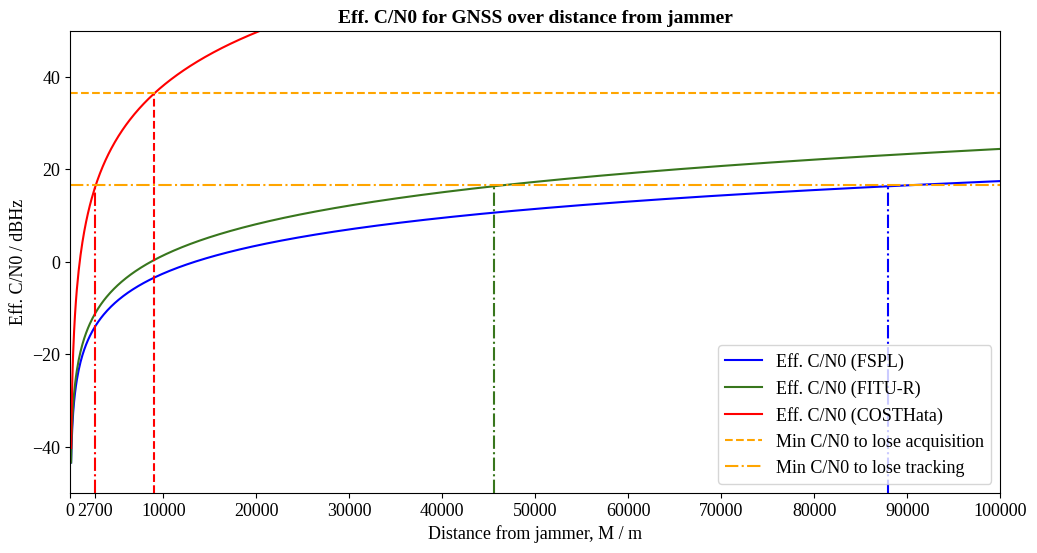

In [9]:
%matplotlib inline
plt.rcParams.update({'font.size': 13, 'font.family': "Tinos"})
# clear and set up graph
plt.clf()
fig, ax = plt.subplots()

x_upperlimit = 100000
x_step = 10000

ax.set_xlabel("Distance from jammer, M / m")
ax.set_ylabel("Eff. C/N0 / dBHz")
ax.set_title("Eff. C/N0 for GNSS over distance from jammer", fontsize=14, fontweight="bold")

GPS_methods = ["FSPL", "FITU-R", "COSTHata"]
colorGPS = {
    "FSPL":  "blue",
    "COSTHata": "red",
    "FITU-R": "#38761d"
}
val = [i for i in range(0, x_upperlimit+1, x_step)]
for method in GPS_methods:
  points = getValuesJammer(0, x_upperlimit, 100, method)
  ax.plot(points[0], points[1], label=f"Eff. C/N0 ({method})", color=colorGPS[method])

  loseacqD = findDistanceJammer(loseacq_JSratio, method)
  losetrackD = findDistanceJammer(losetrack_JSratio, method)
  if method=="COSTHata":
    val.append(int(round(losetrackD/100,0)*100))

  ax.plot([loseacqD, loseacqD], [-50, effCN0(loseacq_JSratio)], color=colorGPS[method], linestyle="--")
  ax.plot([losetrackD, losetrackD], [-50, effCN0(losetrack_JSratio)], color=colorGPS[method], linestyle="-.")

ax.plot([0, x_upperlimit], [effCN0(loseacq_JSratio), effCN0(loseacq_JSratio)], label="Min C/N0 to lose acquisition", color="orange", linestyle="--")
ax.plot([0, x_upperlimit], [effCN0(losetrack_JSratio), effCN0(losetrack_JSratio)], label="Min C/N0 to lose tracking", color="orange", linestyle="-.")

plt.xlim(0, x_upperlimit)
plt.ylim(-50, 50)

val.sort()

ax.set_xticks(val)
ax.set_xticklabels(val)

fig.set_figwidth(12)
fig.set_figheight(6)

ax.legend(fontsize=13)

plt.show()
fig.savefig("Eff. CN0 for GNSS over distance from jammer.png", format='png', dpi=600, bbox_inches = 'tight')